In [1]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import euclidean

### Configuration

In [2]:
DATASET_PATH = "./composite_database"
PLAYER_IDS = ["Cristiano Ronaldo", "Lionel Messi", "Mohamed Salah"]
IMG_SIZE = (92, 112)   # width, height
N_COMPONENTS = 150
MODEL_DIR = "models"
RANDOM_STATE = 42

for i in range(1, 38):
    PLAYER_IDS.append(f's{i}')
    
print(PLAYER_IDS)

['Cristiano Ronaldo', 'Lionel Messi', 'Mohamed Salah', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27', 's28', 's29', 's30', 's31', 's32', 's33', 's34', 's35', 's36', 's37']


### Face Detector

In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_face(gray_img):
    faces = face_cascade.detectMultiScale(
        gray_img,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    if len(faces) == 0:
        return None

    # Largest face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    return gray_img[y:y+h, x:x+w]


### Load The Composte Dataset (With Face Detection)

In [4]:
X, y = [], []

for subject_id in PLAYER_IDS:
    subject_path = os.path.join(DATASET_PATH, subject_id)

    for img_name in os.listdir(subject_path):
        img_path = os.path.join(subject_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        face = detect_face(img)
        if face is None:
            continue

        face = cv2.resize(face, IMG_SIZE)
        X.append(face.flatten())
        y.append(subject_id)

X = np.array(X)
y = np.array(y)

print("Dataset loaded:", X.shape)


Dataset loaded: (351, 10304)


### Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

### Apply PCA (Eigenfaces)

In [6]:
pca = PCA(
    n_components=N_COMPONENTS,
    whiten=True,
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("PCA shape:", X_train_pca.shape)

PCA shape: (263, 150)


### Visualize Eigenfaces

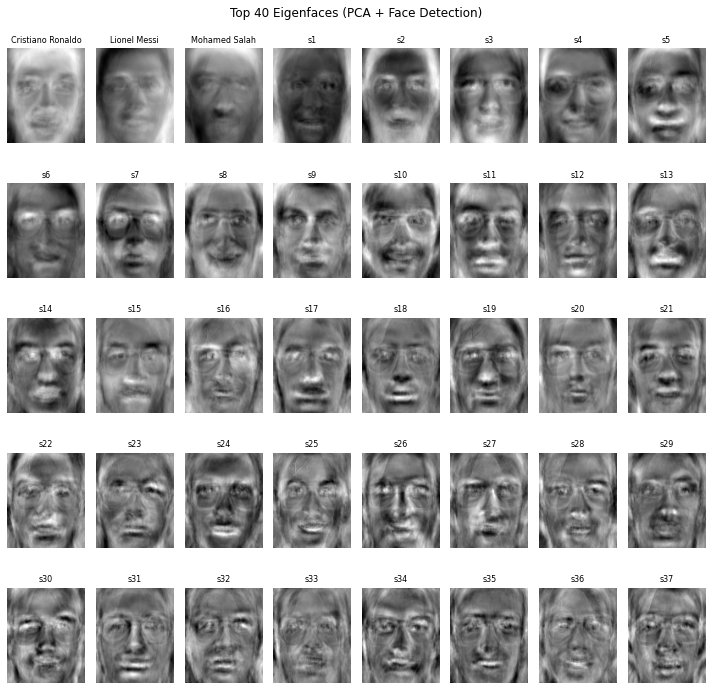

In [7]:
eigenfaces = pca.components_.reshape((N_COMPONENTS, 112, 92))

plt.figure(figsize=(10, 10))
for i in range(40):
    plt.subplot(5, 8, i + 1)
    plt.imshow(eigenfaces[i], cmap="gray")
    plt.title(f"{PLAYER_IDS[i]}", fontsize=8)
    plt.axis("off")

plt.suptitle("Top 40 Eigenfaces (PCA + Face Detection)")
plt.tight_layout()
plt.show()

### Train SVM Classifier

In [8]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma=0.001
)

svm.fit(X_train_pca, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Closed-Set Accuracy (Reference)

In [9]:
y_pred = svm.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

print(f"Closed-set accuracy: {accuracy * 100:.2f}%")

Closed-set accuracy: 96.59%


### Compute Class Centroids

In [10]:
class_centroids = {}

for label in np.unique(y_train):
    class_centroids[label] = np.mean(
        X_train_pca[y_train == label],
        axis=0
    )

### Learn Distance Threshold (95%)

In [11]:
distances = []

for i in range(len(X_train_pca)):
    label = y_train[i]
    centroid = class_centroids[label]
    d = euclidean(X_train_pca[i], centroid)
    distances.append(d)

DIST_THRESHOLD = np.percentile(distances, 97.5)
print("Distance threshold:", DIST_THRESHOLD)

Distance threshold: 14.646174816969467


### Recognition Function

In [ ]:
def recognize_face(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return "Invalid image"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    face = detect_face(gray)
    if face is None:
        return "No face detected"

    face = cv2.resize(face, IMG_SIZE)
    face_flat = face.flatten().reshape(1, -1)

    face_pca = pca.transform(face_flat)

    predicted_label = svm.predict(face_pca)[0]
    centroid = class_centroids[predicted_label]
    distance = euclidean(face_pca[0], centroid)

    if distance > DIST_THRESHOLD:
        return "Unknown person"
    else:
        return f"Recognized as {predicted_label}"

In [ ]:
print(recognize_face("test_mo.jpg"))

Invalid image


### Save Everything

In [14]:
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(pca, f"{MODEL_DIR}/pca_eigenfaces.pkl")
joblib.dump(svm, f"{MODEL_DIR}/svm_classifier.pkl")
joblib.dump(class_centroids, f"{MODEL_DIR}/class_centroids.pkl")
joblib.dump(DIST_THRESHOLD, f"{MODEL_DIR}/distance_threshold.pkl")

print("All models saved successfully.")

All models saved successfully.
